# IPL second innings win predictor

Win probability for the chasing team from the live match state. Trained on
ball-by-ball data, 2008-2019.

The part that actually matters here is the train/test split. Every ball of a
match has the same final result, so a random row split lets the model see part
of a game in training and the rest in test, which leaks the outcome. Splitting
by match fixes that.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
teams = ["Sunrisers Hyderabad", "Mumbai Indians", "Royal Challengers Bangalore",
         "Kolkata Knight Riders", "Kings XI Punjab", "Chennai Super Kings",
         "Rajasthan Royals", "Delhi Capitals"]

In [2]:
matches = pd.read_csv("../data/ipl/matches.csv")
deliveries = pd.read_csv("../data/ipl/deliveries.csv")

# first innings total = the target the chasing side needs
first = (deliveries.groupby(["match_id", "inning"])["total_runs"].sum().reset_index())
first = first[first["inning"] == 1]

In [3]:
# match table: 8 current teams, rename Delhi, drop D/L matches
m = matches.copy()
m["winner"] = m["winner"].replace("Delhi Daredevils", "Delhi Capitals")
m = m[m["dl_applied"] == 0]
m = m.merge(first[["match_id", "total_runs"]], left_on="id", right_on="match_id")
m = m[["match_id", "city", "winner", "total_runs"]].dropna(subset=["winner"])

In [4]:
df = m.merge(deliveries, on="match_id")
df = df[df["inning"] == 2].copy()
df["batting_team"] = df["batting_team"].replace("Delhi Daredevils", "Delhi Capitals")
df["bowling_team"] = df["bowling_team"].replace("Delhi Daredevils", "Delhi Capitals")
df = df[df["batting_team"].isin(teams) & df["bowling_team"].isin(teams)]

df["current_score"] = df.groupby("match_id")["total_runs_y"].cumsum()
df["runs_left"] = df["total_runs_x"] - df["current_score"]
df["balls_left"] = 126 - (df["over"] * 6 + df["ball"])
df["is_wicket"] = df["player_dismissed"].notna().astype(int)
df["wickets"] = 10 - df.groupby("match_id")["is_wicket"].cumsum()
df["cur_run_rate"] = (df["current_score"] * 6) / (120 - df["balls_left"])
df["req_run_rate"] = (df["runs_left"] * 6) / df["balls_left"]
df["result"] = (df["batting_team"] == df["winner"]).astype(int)

In [5]:
features = ["batting_team", "bowling_team", "city", "runs_left", "balls_left",
           "wickets", "total_runs_x", "cur_run_rate", "req_run_rate"]
final = df[["match_id"] + features + ["result"]]
final = final[final["balls_left"] > 0].replace([np.inf, -np.inf], np.nan).dropna()
print(final.shape)

X = final[features]
y = final["result"]
groups = final["match_id"]

def build():
    ct = ColumnTransformer([("ohe", OneHotEncoder(handle_unknown="ignore"),
                             ["batting_team", "bowling_team", "city"])],
                           remainder="passthrough")
    return Pipeline([("enc", ct), ("model", LogisticRegression(solver="liblinear"))])

(63068, 11)


Same model, two splits. The random split looks better but it's the leak, not skill.

In [6]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=SEED)
leaky = build().fit(Xtr, ytr)
print(f"random row split (leaky): {accuracy_score(yte, leaky.predict(Xte)):.3f}")

train_idx, test_idx = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
                           .split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
print(f"split by match: train {groups.iloc[train_idx].nunique()} games, "
      f"test {groups.iloc[test_idx].nunique()} games")

random row split (leaky): 0.810
split by match: train 436 games, test 110 games


accuracy 0.728
log loss 0.584


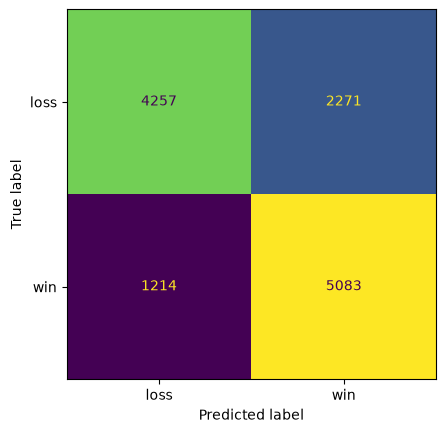

In [7]:
pipe = build().fit(X_train, y_train)
pred = pipe.predict(X_test)
proba = pipe.predict_proba(X_test)[:, 1]
print(f"accuracy {accuracy_score(y_test, pred):.3f}")
print(f"log loss {log_loss(y_test, proba):.3f}")
ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                       display_labels=["loss", "win"]).plot(colorbar=False)
plt.show()

In [8]:
# random forest, evaluated the same honest way (nowhere near the fake 99% people report)
rf = Pipeline([("enc", ColumnTransformer(
    [("ohe", OneHotEncoder(handle_unknown="ignore"),
      ["batting_team", "bowling_team", "city"])], remainder="passthrough")),
    ("model", RandomForestClassifier(n_estimators=200, max_depth=12,
                                     random_state=SEED, n_jobs=-1))]).fit(X_train, y_train)
print(f"random forest accuracy {accuracy_score(y_test, rf.predict(X_test)):.3f}")

random forest accuracy 0.693


In [9]:
# sanity check: probability should climb as the chase stays on track
def prob(score, overs, wkts, target=180):
    balls_left = 120 - int(overs * 6)
    runs_left = target - score
    s = pd.DataFrame([{"batting_team": "Mumbai Indians", "bowling_team": "Chennai Super Kings",
                       "city": "Mumbai", "runs_left": runs_left, "balls_left": balls_left,
                       "wickets": 10 - wkts, "total_runs_x": target,
                       "cur_run_rate": score / overs, "req_run_rate": runs_left * 6 / balls_left}])
    return pipe.predict_proba(s)[0, 1]

for sc, ov, wk in [(40, 5, 1), (85, 10, 2), (130, 15, 4), (160, 18, 6)]:
    print(f"{sc}/{wk} after {ov} overs -> {prob(sc, ov, wk):.0%}")

40/1 after 5 overs -> 60%
85/2 after 10 overs -> 73%
130/4 after 15 overs -> 72%
160/6 after 18 overs -> 66%


In [10]:
pipe.fit(X, y)  # refit on all data for the app
with open("../ipl-app/pipe.pkl", "wb") as f:
    pickle.dump(pipe, f)